## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Aprendizaje Automático
**Práctica:** Análisis de Componentes Principales o PCA (Principal Component Analysis)

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

**Objetivo:** Aplicar PCA (Análisis de Componentes Principales) para reducir la dimensionalidad del dataset de evaluaciones de películas y visualizar los patrones entre ellas utilizando los primeros dos componentes principales.

### 1. Importar librerías y cargar el dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('peliculas_top_evaluaciones.csv', index_col=0)
df.shape

(50, 50)

In [3]:
df.head()

,404,654,12,449,275,415,536,302,233,392,...,268,726,398,641,915,144,362,649,150,523
Star Wars (1977),5.0,4.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,5.0,...,3.0,4.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0
Contact (1997),0.0,2.0,4.0,4.0,5.0,5.0,4.0,4.0,2.0,4.0,...,0.0,2.0,0.0,3.0,0.0,4.0,3.0,3.0,5.0,0.0
Fargo (1996),0.0,3.0,5.0,4.0,5.0,5.0,4.0,5.0,4.0,1.0,...,5.0,2.0,3.0,0.0,5.0,5.0,5.0,4.0,3.0,5.0
Return of the Jedi (1983),5.0,3.0,5.0,4.0,5.0,5.0,2.0,5.0,3.0,4.0,...,2.0,3.0,3.0,5.0,4.0,5.0,5.0,4.0,5.0,3.0
Liar Liar (1997),0.0,3.0,2.0,4.0,4.0,4.0,1.0,4.0,3.0,4.0,...,0.0,4.0,0.0,5.0,0.0,4.0,0.0,3.0,0.0,0.0


El dataset contiene 50 películas (filas) y 50 clientes (columnas). Cada celda representa la calificación que un cliente le dio a una película (de 0 a 5). Un valor de 0 significa que el cliente no la calificó.

### 2. Escalar los datos

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)
print('Datos escalados — Media:', X_scaled.mean().round(4), '| Desv. Std:', X_scaled.std().round(4))

Datos escalados — Media: 0.0 | Desv. Std: 1.0


Antes de aplicar PCA es necesario escalar los datos para que todas las variables (clientes) tengan media cero y desviación estándar uno. 

Sin este paso, los clientes que usan escalas más grandes dominarían las componentes principales y sesgarían los resultados.

### 3. Calcular el modelo PCA

In [5]:
# Calculamos PCA con todas las componentes posibles (50)
pca_full = PCA()
pca_full.fit_transform(X_scaled)

print('Total de componentes calculadas:', len(pca_full.explained_variance_ratio_))

Total de componentes calculadas: 50


In [6]:
# Varianza explicada acumulada
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# ¿Con cuántas componentes llegamos al 80% de la varianza?
n_componentes_80 = int(np.argmax(varianza_acumulada >= 0.80)) + 1
print(f'Componentes necesarias para explicar el 80% de la varianza: {n_componentes_80}')
print(f'Con 2 componentes se explica el: {varianza_acumulada[1]*100:.2f}% de la varianza')

Componentes necesarias para explicar el 80% de la varianza: 15
Con 2 componentes se explica el: 32.64% de la varianza


### 4. Gráfica de varianza explicada acumulada

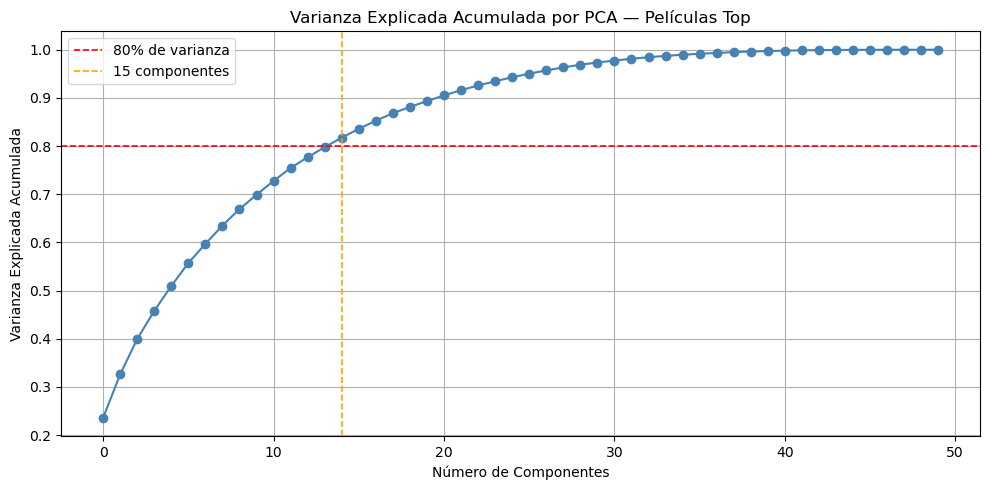

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', color='steelblue')
plt.axhline(y=0.80, color='red', linestyle='--', linewidth=1.2, label='80% de varianza')
plt.axvline(x=n_componentes_80 - 1, color='orange', linestyle='--', linewidth=1.2,
            label=f'{n_componentes_80} componentes')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada por PCA — Películas Top')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observaciones:**

* La curva muestra cómo va aumentando la información capturada conforme agregamos más componentes principales.
* La línea roja indica el umbral del 80% de varianza. Se necesitan aproximadamente 15 componentes para alcanzarlo.
* El dataset de películas tiene una varianza bastante distribuida entre todos los clientes, lo que significa que no hay un patrón muy dominante.
* Con solo 2 componentes se captura alrededor del 32.6% de la varianza total.

### 5. Gráfica 2D con los dos primeros componentes principales

In [8]:
# Aplicamos PCA con solo 2 componentes
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

print('Varianza explicada por componente:')
for i, var in enumerate(pca2.explained_variance_ratio_):
    print(f'  Componente {i+1}: {var*100:.2f}%')
print(f'  Total acumulado: {np.sum(pca2.explained_variance_ratio_)*100:.2f}%')

Varianza explicada por componente:
  Componente 1: 23.59%
  Componente 2: 9.05%
  Total acumulado: 32.64%


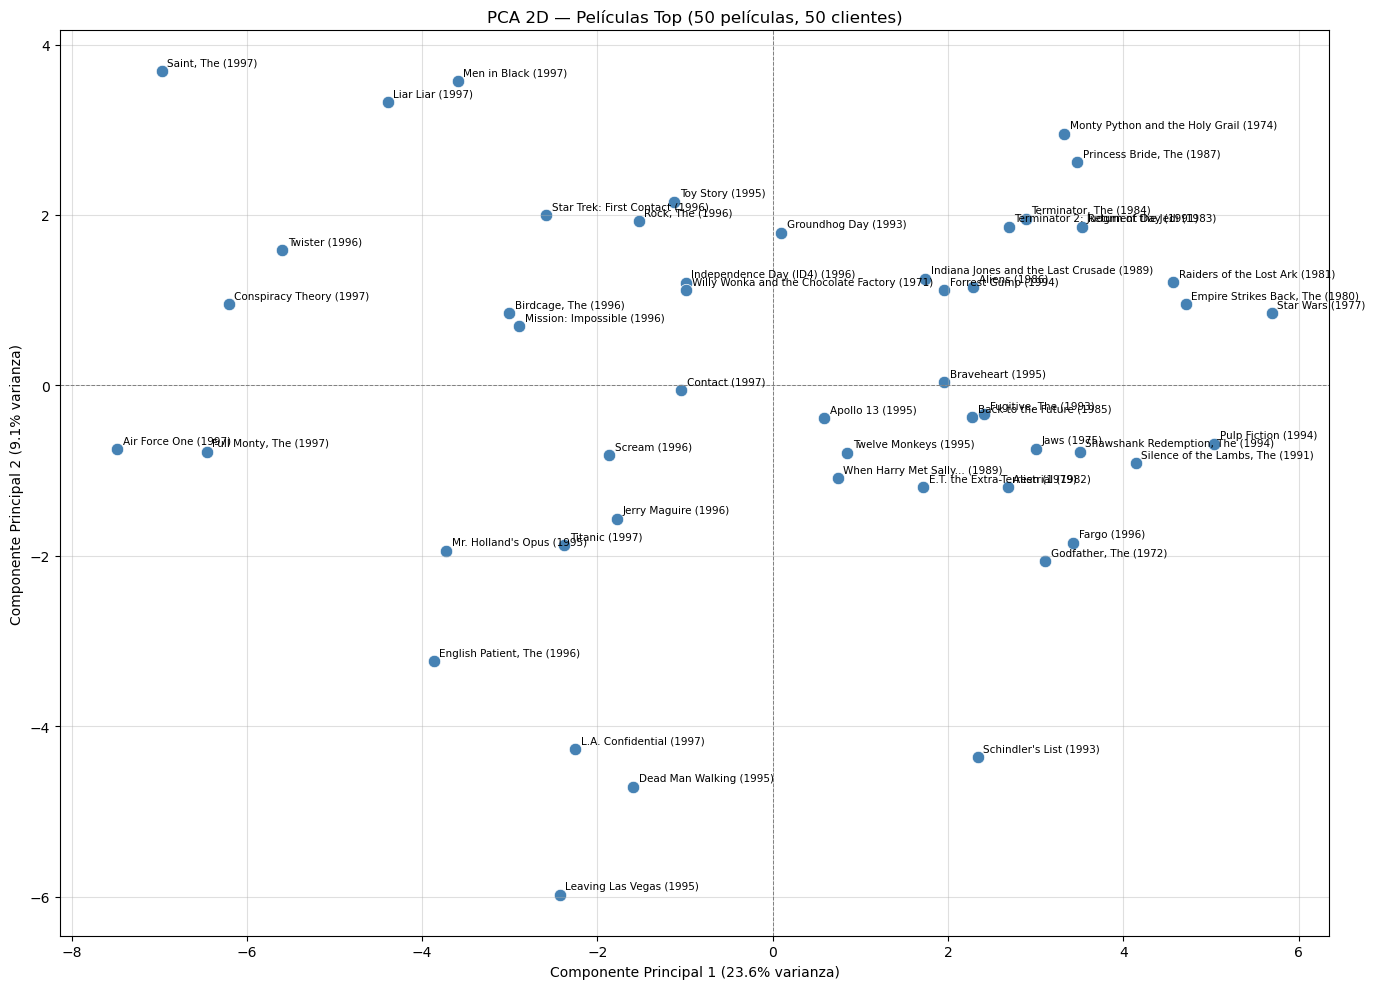

In [9]:
fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(X_pca2[:, 0], X_pca2[:, 1],
           color='steelblue', edgecolors='white', s=80, linewidths=0.5)

# Etiquetas para cada película
for i, nombre in enumerate(df.index):
    ax.annotate(nombre, (X_pca2[i, 0], X_pca2[i, 1]),
                fontsize=7.5, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel(f'Componente Principal 1 ({pca2.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'Componente Principal 2 ({pca2.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('PCA 2D — Películas Top (50 películas, 50 clientes)')
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Observaciones:**

* Cada punto representa una película, ubicada en el espacio de los dos primeros componentes principales.
* La posición de cada película está determinada por la combinación lineal de las evaluaciones de los 50 clientes que más varianza captura.
* Películas que aparecen cercanas entre sí tienden a ser evaluadas de manera similar por los mismos clientes (por ejemplo, películas del mismo género o del mismo director).
* Películas en extremos opuestos del gráfico son calificadas de forma muy diferente o por perfiles de cliente distintos.

**Nota:** Como la varianza capturada con 2 componentes es ~32.6%, esta visualización nos da una aproximación de los patrones, pero no toda la información está representada. Para análisis más precisos convendría usar más componentes (al menos 15 para cubrir el 80% de la varianza).